# Semana 1 · Solución de la práctica de flujo vehicular
**Material:** `tema01_curso_ml.html` y `tema01_clase_02_practica.html` (archivos suministrados).

Este notebook responde los bloques «Tu turno» y el reto integrador. La actividad corresponde a las fases 2 (entendimiento) y 3 (preparación) de CRISP-DM. No se entrena un predictor en esta semana.

**Estado:** ejecutado sobre el `Flujo_vehicular.csv` suministrado, con resultados y gráficos guardados. Para reproducirlo, copia el CSV en `data/raw/`. El código de cálculo se ejecutó secuencialmente; las salidas se capturaron sin iniciar un servidor Jupyter.

**Alcance:** se reproduce el split aleatorio didáctico; un pronóstico de meses futuros requiere una separación temporal. Se mantienen los ceros sospechosos bajo revisión y se muestra por separado la transformación que solicita la clase.


## 0. Entorno y repositorio
La estructura entregada contiene datos separados del código, módulos `src/data.py` y `src/features.py`, notebooks, dependencias y reglas de exclusión. El README explica Git y los pasos pendientes de publicación. Un ZIP no demuestra historial de commits ni conexión SSH; esas comprobaciones deben hacerse en la cuenta del alumno.


In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/data.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Abre el notebook dentro de la carpeta actividad_ml.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from src.data import read_flujo, NormalizeText, PESADOS, FEATURES, RESUMEN, ADULT_COLUMNS
from src.features import compare_imputers, build_preprocessor
RANDOM_STATE = 42
pd.set_option('display.max_columns', 40)


## 1. Carga y encoding
Cada fila representa un peaje en un mes. `latin-1` es el encoding indicado por el material. El número 10 781 × 23 es una referencia del HTML y se contrasta, no se impone, sobre el CSV disponible.


In [2]:
df = read_flujo(ROOT)
print('Dimensiones calculadas:', df.shape)
display(df.head())
try:
    pd.read_csv(ROOT / 'data/raw/Flujo_vehicular.csv', encoding='utf-8')
except UnicodeDecodeError as error:
    print('Al usar UTF-8:', error)
else:
    print('Esta copia permite UTF-8; no se debe inventar un error de encoding.')


Dimensiones calculadas: (10781, 23)


,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


Al usar UTF-8: 'utf-8' codec can't decode byte 0xed in position 8: invalid continuation byte


## 2. EDA antes de limpiar
El porcentaje de nulos es `isna().mean() * 100`; sin multiplicar por 100 se obtiene una proporción. La diferencia entre media y mediana sugiere asimetría, pero se complementa con el histograma. Los duplicados exactos no deben borrarse sin investigar la unidad de observación.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10781 non-null  int64  
 1   ADMINIST                 10781 non-null  object 
 2   CODIGO_PEAJE             10781 non-null  object 
 3   DEPARTAMENTO             10781 non-null  object 
 4   NOMBRE_PEAJE             10781 non-null  object 
 5   VEH_LIGEROS_TAR_DIF      10781 non-null  int64  
 6   VEH_LIGEROS_AUTOMOVILES  10768 non-null  float64
 7   VEH_PESADOS_TAR_DIF      10781 non-null  int64  
 8   VEH_PESADOS__2E          10773 non-null  float64
 9   VEH_PESADOS_3E           10773 non-null  float64
 10  VEH_PESADOS_4E           10773 non-null  float64
 11  VEH_PESADOS_5E           10773 non-null  float64
 12  VEH_PESADOS_6E           10773 non-null  float64
 13  VEH_PESADOS_7E           10773 non-null  float64
 14  VEH_LIGEROS_TOTAL     

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,10781.0,NaN,NaN,NaN,5390.0,3112.35096,0.0,2695.0,5390.0,8085.0,10780.0
ADMINIST,10781,2,Concesionado,7419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODIGO_PEAJE,10781,82,13PE08CDS1,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEPARTAMENTO,10781,22,Puno,1208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_PEAJE,10781,82,Ciudad de Dios,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VEH_LIGEROS_TAR_DIF,10781.0,NaN,NaN,NaN,1896.093034,6297.010934,0.0,0.0,0.0,376.0,71734.0
VEH_LIGEROS_AUTOMOVILES,10768.0,NaN,NaN,NaN,44374.207467,66000.775351,0.0,11284.0,23460.5,47658.25,796486.0
VEH_PESADOS_TAR_DIF,10781.0,NaN,NaN,NaN,817.151841,2710.769041,0.0,0.0,0.0,0.0,38818.0
VEH_PESADOS__2E,10773.0,NaN,NaN,NaN,8630.367586,10942.912132,0.0,2125.0,4218.0,10589.0,73590.0
VEH_PESADOS_3E,10773.0,NaN,NaN,NaN,7666.940685,9845.497573,0.0,1300.0,3573.0,8678.0,78943.0


,tipo,nulos,pct_nulos,unicos
VEH_LIGEROS_AUTOMOVILES,float64,13,0.120583,9304
VEH_PESADOS_6E,float64,8,0.074205,7514
VEH_PESADOS_7E,float64,8,0.074205,1033
VEH_PESADOS_5E,float64,8,0.074205,4489
VEH_PESADOS_4E,float64,8,0.074205,4232
VEH_PESADOS_3E,float64,8,0.074205,7057
VEH_PESADOS__2E,float64,8,0.074205,7319
VEH_LIGEROS_TAR_DIF,int64,0,0.000000,2634
NOMBRE_PEAJE,object,0,0.000000,82
DEPARTAMENTO,object,0,0.000000,22


Duplicados exactos adicionales: 0
VEH_PESADOS_6E: media=11708.79; mediana=4172.00; diferencia=7536.79
Cociente media/mediana: 2.8065173764993783
Observación 1: columnas con nulos: ['VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E', 'VEH_PESADOS_7E']
Observación 2: revisar asimetría con media, mediana e histograma.
Observación 3: filas con VEH_TOTAL=0: 741


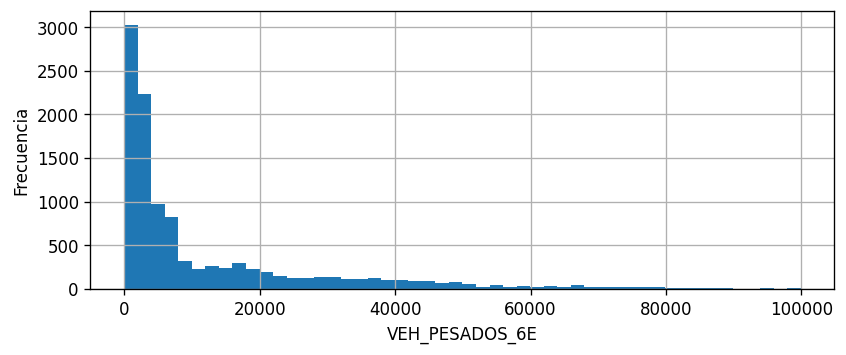

In [3]:
df.info()
display(df.describe(include='all').T)
quality = pd.DataFrame({'tipo': df.dtypes.astype(str), 'nulos': df.isna().sum(),
                        'pct_nulos': df.isna().mean()*100, 'unicos': df.nunique()})
display(quality.sort_values('pct_nulos', ascending=False))
print('Duplicados exactos adicionales:', df.duplicated().sum())
col = 'VEH_PESADOS_6E'
mean, median = df[col].mean(), df[col].median()
print(f'{col}: media={mean:.2f}; mediana={median:.2f}; diferencia={mean-median:.2f}')
print('Cociente media/mediana:', mean/median if median != 0 else 'No definido: mediana 0')
print('Observación 1: columnas con nulos:', quality.index[quality.nulos > 0].tolist())
print('Observación 2: revisar asimetría con media, mediana e histograma.')
print('Observación 3: filas con VEH_TOTAL=0:', df['VEH_TOTAL'].eq(0).sum())
df[col].hist(bins=50, figsize=(8,3)); plt.xlabel(col); plt.ylabel('Frecuencia'); plt.show()


## 3. Clasificación semántica
`ANIO`, `MES` y `PERIODO` son temporales: no entran como conteos de vehículos ni se imputan con su mediana. Pueden ser características útiles si se representan adecuadamente (tendencia, mes cíclico). `CODIGO_PEAJE` es un identificador categórico aunque se almacene como número. `ID` identifica filas. Los conteos son cuantitativos discretos; los índices medios diarios son promedios.


In [4]:
cat_cols = ['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'NOMBRE_PEAJE']
cat_cols = [c for c in cat_cols if c in df]
temporal_cols = [c for c in ['ANIO', 'MES', 'PERIODO'] if c in df]
num_cols = [c for c in df.select_dtypes('number') if c not in ['ID'] + cat_cols + temporal_cols]
display(df.nunique().sort_values())
print('Numéricas:', num_cols, '\nCategóricas:', cat_cols, '\nTemporales:', temporal_cols)
for c in cat_cols:
    print('\n', c)
    display(df[c].value_counts(dropna=False))


ADMINIST                       2
MES                           12
ANIO                          12
DEPARTAMENTO                  22
CODIGO_PEAJE                  82
NOMBRE_PEAJE                  82
PERIODO                      138
VEH_PESADOS_7E              1033
VEH_PESADOS_TAR_DIF         1778
VEH_LIGEROS_TAR_DIF         2634
VEH_PESADOS_4E              4232
VEH_PESADOS_5E              4489
VEH_PESADOS_3E              7057
VEH_PESADOS__2E             7319
VEH_PESADOS_6E              7514
VEH_PESADOS_IMD             7751
VEH_LIGEROS_IMD             8333
VEH_IMD                     8927
VEH_PESADOS_TOTAL           9086
VEH_LIGEROS_AUTOMOVILES     9304
VEH_LIGEROS_TOTAL           9326
VEH_TOTAL                   9585
ID                         10781
dtype: int64

Numéricas: ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD'] 
Categóricas: ['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'NOMBRE_PEAJE'] 
Temporales: ['ANIO', 'MES', 'PERIODO']

 ADMINIST


ADMINIST
Concesionado       7419
No concesionado    3362
Name: count, dtype: int64


 CODIGO_PEAJE


CODIGO_PEAJE
13PE08CDS1     150
13PE10AMEO1    150
04PE1SCAM1     138
12PE3NCRA1     138
15PE1SCLA1     138
              ... 
08PE30CQCM1     78
14PE1NISNC1     68
04PE1SDQLC1     68
04PE1SDPDB1     54
02PE1NSNT1       4
Name: count, Length: 82, dtype: int64


 DEPARTAMENTO


DEPARTAMENTO
Puno             1208
Lima             1194
Arequipa         1087
Piura             965
La Libertad       714
Ica               690
Lambayeque        608
Junín             552
Cusco             483
Áncash            418
Madre de Dios     414
Ayacucho          413
Moquegua          413
San Martín        402
Tacna             276
Amazonas          276
Apurímac          262
Cajamarca         138
Tumbes            138
Huánuco           114
San Martin         12
Apurimac            4
Name: count, dtype: int64


 NOMBRE_PEAJE


NOMBRE_PEAJE
Ciudad de Dios           150
Menocucho (Quirihuac)    150
Camaná                   138
Casaracra-Concesión      138
Chilca                   138
                        ... 
Quincemil                 78
San Nicolás               68
Quilca                    68
Punta Bombón              54
Santa                      4
Name: count, Length: 82, dtype: int64

## 4. Inconsistencias de categorías
Se aplica el mapa explícito del HTML y se eliminan espacios periféricos. Se reporta cuánto cambió la cardinalidad sin obligar a que cualquier versión del CSV tenga exactamente 20 departamentos. La búsqueda de nombres semejantes solo propone candidatos: no fusiona peajes distintos automáticamente.


In [5]:
variants = ['San Martín', 'San Martin', 'Apurímac', 'Apurimac']
display(df['DEPARTAMENTO'].value_counts().reindex(variants, fill_value=0))
df_norm = NormalizeText().fit_transform(df)
print('Departamentos antes/después:', df['DEPARTAMENTO'].nunique(), df_norm['DEPARTAMENTO'].nunique())
import unicodedata
names = pd.Series(df_norm['NOMBRE_PEAJE'].dropna().unique(), name='nombre')
def review_key(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s).casefold())
                   if unicodedata.category(c) != 'Mn')
review = pd.DataFrame({'nombre': names, 'clave': names.map(review_key)})
display(review[review.duplicated('clave', keep=False)].sort_values('clave'))
print('Los candidatos requieren revisar código, ubicación y fuente antes de agregar un mapa.')


DEPARTAMENTO
San Martín    402
San Martin     12
Apurímac      262
Apurimac        4
Name: count, dtype: int64

Departamentos antes/después: 22 20


,nombre,clave


Los candidatos requieren revisar código, ubicación y fuente antes de agregar un mapa.


## 5. Mecanismos de ausencia: evidencia y límites
MCAR significa independencia respecto de valores observados y no observados. MAR supone que, condicionando en lo observado, la ausencia no depende de los valores que faltan. MNAR mantiene dependencia de información no observada.

El HTML concentra ocho filas con faltantes de vehículos pesados en junio de 2025. Esto motiva investigar el proceso de reporte y es compatible con una explicación temporal bajo MAR, pero **no prueba MAR ni descarta MNAR**. Bajo MCAR no se exige que haya faltantes en absolutamente todos los años: importa comparar tasas considerando sus tamaños y la incertidumbre. Tampoco imputar bajo MCAR garantiza preservar varianza o relaciones.


In [6]:
mask = df_norm[PESADOS].isna().any(axis=1)
display(df_norm.loc[mask, ['NOMBRE_PEAJE', 'ANIO', 'MES', 'VEH_TOTAL']])
by_year = df_norm.assign(nulo=mask).groupby('ANIO')['nulo'].agg(['sum','count','mean'])
by_year['pct'] = by_year['mean']*100
display(by_year.drop(columns='mean'))
display(df_norm.assign(nulo=mask).groupby(['ANIO','MES'])['nulo'].agg(['sum','count','mean']).query('sum > 0'))
print('Conclusión: describir la concentración observada; MAR temporal es una hipótesis, no una demostración.')


,NOMBRE_PEAJE,ANIO,MES,VEH_TOTAL
10756,Ambo,2025,6,0
10759,Cancas,2025,6,0
10760,Cátac,2025,6,0
10763,Cuculí (Pomalca),2025,6,0
10774,Rumichaca,2025,6,0
10775,Saylla,2025,6,0
10777,Socos,2025,6,0
10779,Tunán,2025,6,0


,sum,count,pct
ANIO,,,
2014,0,924,0.000000
2015,0,888,0.000000
2016,0,912,0.000000
2017,0,912,0.000000
2018,0,924,0.000000
2019,0,927,0.000000
2020,0,948,0.000000
2021,0,972,0.000000
2022,0,972,0.000000


,,sum,count,mean
ANIO,MES,,,
2025,6,8,79,0.101266


Conclusión: describir la concentración observada; MAR temporal es una hipótesis, no una demostración.


## 6. Ceros sospechosos y bandera
El material registra 741/10 781 ≈ 6,8732 % de filas con total cero. Una caída brusca motiva revisión, pero puede reflejar un cierre, una interrupción de actividad o falta de reporte. **Un cero no identifica por sí mismo MNAR ni ausencia.**

Para cumplir el ejercicio se construye `df_clean` bajo el supuesto didáctico explícito «todos los totales cero son sin reporte». `df_norm` permanece intacto. La bandera conserva la regla aplicada, no prueba que el dato sea faltante. El pipeline posterior excluye esos resúmenes; no usará esa bandera como predictor. Si el objetivo fuera `VEH_TOTAL`, una bandera derivada del objetivo podría producir fuga.

Eliminar todas esas filas puede perder información y alterar la composición por peaje o periodo. Mantenerlas tampoco soluciona por sí solo la ausencia: se debe definir el uso y verificar la fuente.


In [7]:
zero = df_norm['VEH_TOTAL'].eq(0)
print('Ceros:', int(zero.sum()), 'porcentaje:', float(zero.mean()*100))
options = df_norm.loc[zero & df_norm['NOMBRE_PEAJE'].ne('Ambo'), 'NOMBRE_PEAJE'].dropna().unique()
if len(options):
    other = sorted(options)[0]
    print('Otro peaje:', other)
    history = df_norm.loc[df_norm['NOMBRE_PEAJE'].eq(other)].sort_values(['ANIO','MES'])
    display(history[['ANIO','MES','VEH_TOTAL']].tail(18))
else:
    print('No hay otro peaje con ceros en esta copia; no se inventa uno.')
df_clean = df_norm.copy()
df_clean['cero_total_sospechoso'] = zero.astype(int)
df_clean.loc[zero, RESUMEN] = np.nan  # Supuesto didáctico, pendiente de confirmación de la fuente.
df_clean['sin_reporte'] = zero.astype(int)
print('No se convierten todos los ceros de subcategorías: pueden ser conteos válidos.')


Ceros: 741 porcentaje: 6.87320285687784
Otro peaje: Aguas Calientes


,ANIO,MES,VEH_TOTAL
9406,2024,1,23785
9487,2024,2,23030
9568,2024,3,20794
9649,2024,4,17284
9730,2024,5,19300
9811,2024,6,19695
9892,2024,7,21936
9973,2024,8,23521
10051,2024,9,20675
10132,2024,10,21061


No se convierten todos los ceros de subcategorías: pueden ser conteos válidos.


## 7. Separación antes de estimar parámetros
Se usa 80/20 con semilla 42 para reproducir el ejercicio. La semilla fija la partición, no garantiza calidad ni hace aleatorio a KNN. El mismo conjunto de índices se conserva para numéricas y categóricas.

Esta práctica evalúa recuperación de celdas. Para predecir tráfico futuro, hay que reservar los últimos periodos completos y usar validación temporal dentro del entrenamiento; mezclar meses aleatoriamente puede ser optimista. El EDA global previo es didáctico: en un proyecto predictivo real se reserva test antes de explorar relaciones para tomar decisiones.


In [8]:
train, test = train_test_split(df_clean, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_test = train[FEATURES].copy(), test[FEATURES].copy()
print('Train / test:', X_train.shape, X_test.shape)
display(X_train.isna().sum())
assert set(train.index).isdisjoint(test.index)


Train / test: (8624, 7) (2157, 7)


VEH_LIGEROS_AUTOMOVILES    8
VEH_PESADOS__2E            5
VEH_PESADOS_3E             5
VEH_PESADOS_4E             5
VEH_PESADOS_5E             5
VEH_PESADOS_6E             5
VEH_PESADOS_7E             5
dtype: int64

## 8. Comparación de imputadores
Se oculta el 15 % de valores observados de `VEH_PESADOS_6E` con `RandomState(42)`. Se conserva la verdad separada. Todos los métodos reciben los mismos huecos; los escaladores se ajustan después de ocultarlos.

Se calcula RMSE y MAE en unidades originales. La comparación usa entrenamiento, sin tocar test. Es una evaluación didáctica interna de recuperación, no una evaluación predictiva externa. Ocultar una columna al azar simula MCAR en esa columna y puede favorecer métodos que aprovechan otras columnas observadas; no reproduce la falta simultánea de todos los ejes del HTML. Conviene repetir semillas, ocultar bloques y validar por periodos antes de generalizar.

Los ceros por subcategoría se mantienen porque no están confirmados como ausencias; si la fuente demuestra que son marcadores, la evaluación debe repetirse. La mediana produce una línea horizontal porque predice el mismo valor para todos los huecos. KNN e iterativa pueden acercarse a la diagonal, pero no se garantiza de antemano un ganador. Se reportan negativos sin recortarlos a escondidas.


,metodo,n_ocultos,RMSE,MAE,predicciones_negativas
2,KNN estandarizado,1292,2596.594472,1014.620743,0
1,KNN sin escala,1292,3854.636386,1861.355728,0
3,Iterativa estandarizada,1292,5582.664296,2947.010721,98
0,Mediana,1292,18665.135986,10563.208978,0


Menor RMSE en este experimento: KNN estandarizado


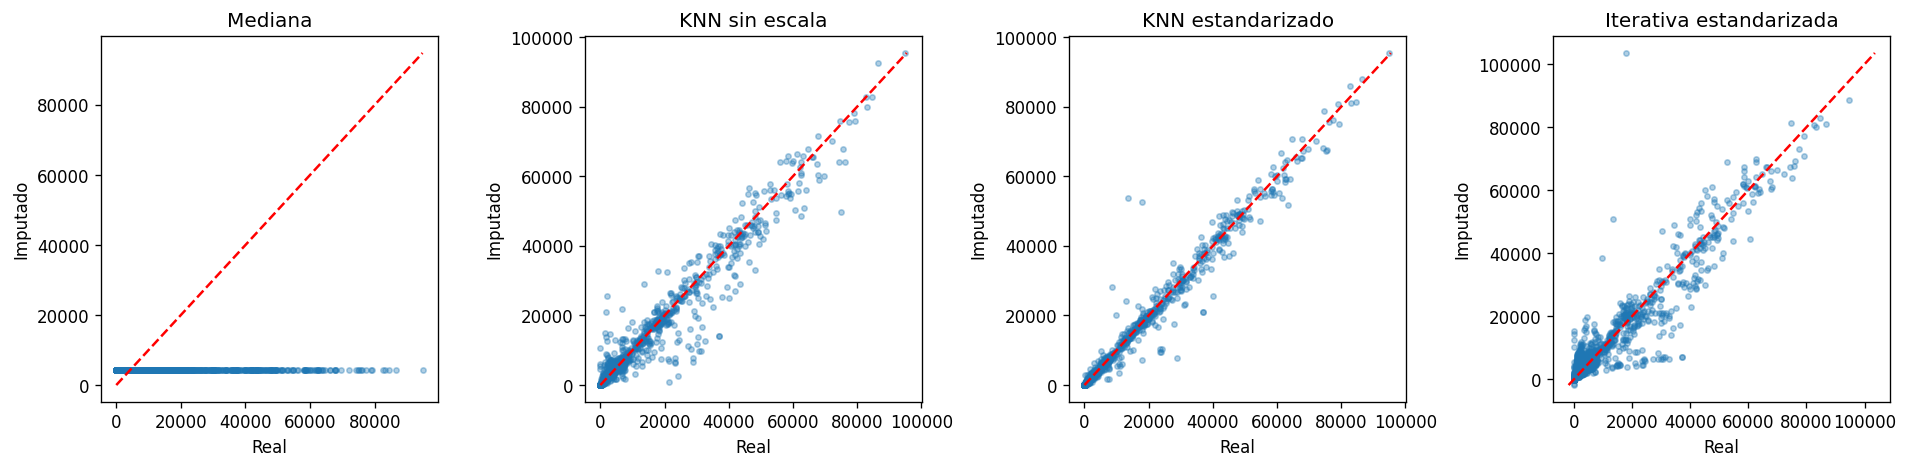

Comparar KNN sin escala frente a KNN estandarizado en la tabla; escalar no garantiza mejorar.


In [9]:
scores, truth, recovered = compare_imputers(X_train, 'VEH_PESADOS_6E')
display(scores)
best = scores.iloc[0]['metodo']
print('Menor RMSE en este experimento:', best)
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, (name, frame) in zip(axes, recovered.items()):
    prediction = frame.loc[truth.index, 'VEH_PESADOS_6E']
    ax.scatter(truth, prediction, alpha=.35, s=10)
    lo, hi = min(truth.min(), prediction.min()), max(truth.max(), prediction.max())
    ax.plot([lo,hi],[lo,hi], 'r--')
    ax.set(title=name, xlabel='Real', ylabel='Imputado')
plt.tight_layout(); plt.show()
print('Comparar KNN sin escala frente a KNN estandarizado en la tabla; escalar no garantiza mejorar.')


## 9. Moda, One-Hot, coherencia y ColumnTransformer
La moda se ajusta solo con entrenamiento. Una categoría `DESCONOCIDO` sería una alternativa, según el significado del faltante. One-Hot crea una columna por categoría aprendida (sin `drop`); una categoría nueva se representa con ceros en su bloque mediante `handle_unknown="ignore"`.

Que `VEH_TOTAL` coincida con la suma demuestra coherencia aritmética en filas completas, no exactitud, cobertura ni ausencia de errores. Con tolerancia 0,5 tampoco demuestra igualdad exacta. Se cuentan aparte filas que no se pueden verificar.


In [10]:
mode = SimpleImputer(strategy='most_frequent')
mode.fit(train[['DEPARTAMENTO']])
display(pd.DataFrame(mode.transform(test[['DEPARTAMENTO']]), columns=['DEPARTAMENTO'], index=test.index).head())
admin = SimpleImputer(strategy='most_frequent')
admin_train = admin.fit_transform(train[['ADMINIST']])
admin_test = admin.transform(test[['ADMINIST']])
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(admin_train)
print('Categorías ADMINIST aprendidas:', ohe.categories_[0])
print('Columnas One-Hot ADMINIST:', ohe.transform(admin_test).shape[1])
check_cols = ['VEH_TOTAL','VEH_LIGEROS_TOTAL','VEH_PESADOS_TOTAL']
complete = df_norm[check_cols].notna().all(axis=1)
difference = (df_norm['VEH_TOTAL']-df_norm['VEH_LIGEROS_TOTAL']-df_norm['VEH_PESADOS_TOTAL']).abs()
print('Filas verificables:', complete.sum(), 'no verificables:', (~complete).sum())
print('Diferencias > 0.5:', (complete & difference.gt(.5)).sum())
print('Diferencias distintas de 0:', (complete & difference.ne(0)).sum())


,DEPARTAMENTO
8728,Moquegua
761,Tacna
7209,Lambayeque
6685,Piura
8548,Piura


Categorías ADMINIST aprendidas: ['Concesionado' 'No concesionado']
Columnas One-Hot ADMINIST: 2
Filas verificables: 10781 no verificables: 0
Diferencias > 0.5: 0
Diferencias distintas de 0: 0


In [11]:
# Se reajusta el método elegido sobre train original, sin la máscara artificial.
# El pipeline recibe texto crudo y aplica reglas fijas antes del ColumnTransformer.
pipeline = build_preprocessor(FEATURES, ['ADMINIST','DEPARTAMENTO'], method=best)
raw_train = df.loc[train.index, FEATURES + ['ADMINIST','DEPARTAMENTO']]
raw_test = df.loc[test.index, FEATURES + ['ADMINIST','DEPARTAMENTO']]
prepared_train = pipeline.fit_transform(raw_train)
prepared_test = pipeline.transform(raw_test)
print('Shapes finales:', prepared_train.shape, prepared_test.shape)
print('Columnas:', pipeline.named_steps['columns'].get_feature_names_out())
assert prepared_train.shape[1] == prepared_test.shape[1]
assert np.isfinite(prepared_train).all() and np.isfinite(prepared_test).all()
import joblib
joblib.dump(pipeline, ROOT / 'models/preprocesador_flujo.joblib')


Shapes finales: (8624, 29) (2157, 29)
Columnas: ['num__VEH_LIGEROS_AUTOMOVILES' 'num__VEH_PESADOS__2E'
 'num__VEH_PESADOS_3E' 'num__VEH_PESADOS_4E' 'num__VEH_PESADOS_5E'
 'num__VEH_PESADOS_6E' 'num__VEH_PESADOS_7E' 'cat__ADMINIST_Concesionado'
 'cat__ADMINIST_No concesionado' 'cat__DEPARTAMENTO_Amazonas'
 'cat__DEPARTAMENTO_Apurímac' 'cat__DEPARTAMENTO_Arequipa'
 'cat__DEPARTAMENTO_Ayacucho' 'cat__DEPARTAMENTO_Cajamarca'
 'cat__DEPARTAMENTO_Cusco' 'cat__DEPARTAMENTO_Huánuco'
 'cat__DEPARTAMENTO_Ica' 'cat__DEPARTAMENTO_Junín'
 'cat__DEPARTAMENTO_La Libertad' 'cat__DEPARTAMENTO_Lambayeque'
 'cat__DEPARTAMENTO_Lima' 'cat__DEPARTAMENTO_Madre de Dios'
 'cat__DEPARTAMENTO_Moquegua' 'cat__DEPARTAMENTO_Piura'
 'cat__DEPARTAMENTO_Puno' 'cat__DEPARTAMENTO_San Martín'
 'cat__DEPARTAMENTO_Tacna' 'cat__DEPARTAMENTO_Tumbes'
 'cat__DEPARTAMENTO_Áncash']


## 10. Respuesta al reto integrador
1. La carga valida archivo, encoding y columnas; el EDA muestra tipos, estadísticas y porcentajes.
2. Se separan identificadores, categorías, fechas y medidas cuantitativas por significado.
3. Se corrigen variantes de departamentos con mapa explícito y se muestran candidatos de peajes.
4. Se calculan tasas de faltantes por año/mes. Se argumenta una hipótesis temporal con sus límites.
5. Se conserva una bandera y una copia con ceros convertidos, bajo el supuesto declarado de clase.
6. La partición precede a toda imputación y escalado aprendido.
7. Cuatro alternativas se comparan con igual máscara, RMSE, MAE y gráficos en escala original.
8. El pipeline contiene normalización fija y un `ColumnTransformer` ajustado en train, aplicado a test y serializado.

**Conclusión calculada:** sobre 1 292 celdas ocultadas, KNN estandarizado obtuvo RMSE 2 596,59; KNN sin escala 3 854,64; iterativa estandarizada 5 582,66; mediana 18 665,14. KNN estandarizado es el mejor en este experimento interno. La iterativa produjo 98 predicciones negativas entre las celdas evaluadas; no se recortaron antes de medir. El ranking no se generaliza sin más a los faltantes reales simultáneos. La salida final tiene 29 columnas, con 8 624 filas de train y 2 157 de test.
